In [1]:
import pandas as pd


In [10]:
df=pd.read_csv('/content/adult_with_headers.csv')
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [11]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [13]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [16]:
df.duplicated().sum()

np.int64(24)

In [17]:
df.drop_duplicates(inplace=True)

In [26]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder
# select only numerical features for scaling
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
# Standard Scaling
standard_scaler = StandardScaler()
df_standard_scaled = df.copy()
df_standard_scaled[numerical_features] = standard_scaler.fit_transform(data[numerical_features])

# Display the first few rows of the Standard Scaled dataframe
print("\nStandard Scaled DataFrame:")
print(df_standard_scaled.head())


Standard Scaled DataFrame:
        age          workclass    fnlwgt   education  education_num  \
0  0.030390          State-gov -1.063569   Bachelors       1.134777   
1  0.836973   Self-emp-not-inc -1.008668   Bachelors       1.134777   
2 -0.042936            Private  0.245040     HS-grad      -0.420679   
3  1.056950            Private  0.425752        11th      -1.198407   
4 -0.776193            Private  1.408066   Bachelors       1.134777   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income 

In [28]:
#Min-max scaling
min_max_scaler=MinMaxScaler()
df_min_max_scaled=df.copy()
df_min_max_scaled[numerical_features]=min_max_scaler.fit_transform((df[numerical_features]))
# Display the first few rows of the Min-max Scaled data frame
print(df_min_max_scaled.head())

        age          workclass    fnlwgt   education  education_num  \
0  0.301370          State-gov  0.044302   Bachelors       0.800000   
1  0.452055   Self-emp-not-inc  0.048238   Bachelors       0.800000   
2  0.287671            Private  0.138113     HS-grad       0.533333   
3  0.493151            Private  0.151068        11th       0.400000   
4  0.150685            Private  0.221488   Bachelors       0.800000   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0       0.02174           

In [36]:
categorical_columns = df.select_dtypes(include=['object']).columns
# Apply one hot encoding to categorical variables with less than 5 unique categories
for col in categorical_columns:
    if df[col].nunique()<5:
       df_standard_scaled=pd.get_dummies(df,columns=[col],prefix=[col],drop_first=True)
#Display the first few rows of the dataframe after One Hot Encoding
print(df_standard_scaled.head())

        age          workclass    fnlwgt   education  education_num  \
0  0.030390          State-gov -1.063569   Bachelors       1.134777   
1  0.836973   Self-emp-not-inc -1.008668   Bachelors       1.134777   
2 -0.042936            Private  0.245040     HS-grad      -0.420679   
3  1.056950            Private  0.425752        11th      -1.198407   
4 -0.776193            Private  1.408066   Bachelors       1.134777   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0      0.148292     -0.216

In [41]:
categories_to_encode = df.select_dtypes(include=['object']).columns  # Select categorical columns
for col in categories_to_encode:
    if df[col].nunique() >5:# Check number of unique categories
        label_encoder = LabelEncoder()
        df[col] = label_encoder.fit_transform(df[col])

# Display the DataFrame after Label Encoding
print("\nDataFrame after Label Encoding:")
print(df)


DataFrame after Label Encoding:
       age  workclass  fnlwgt  education  education_num  marital_status  \
0       39          7   77516          9             13               4   
1       50          6   83311          9             13               2   
2       38          4  215646         11              9               0   
3       53          4  234721          1              7               2   
4       28          4  338409          9             13               2   
...    ...        ...     ...        ...            ...             ...   
32556   27          4  257302          7             12               2   
32557   40          4  154374         11              9               2   
32558   58          4  151910         11              9               6   
32559   22          4  201490         11              9               4   
32560   52          5  287927         11              9               2   

       occupation  relationship    race  capital_gain  capital_los

Text(0.5, 1.0, 'Histogram of skewed feature')

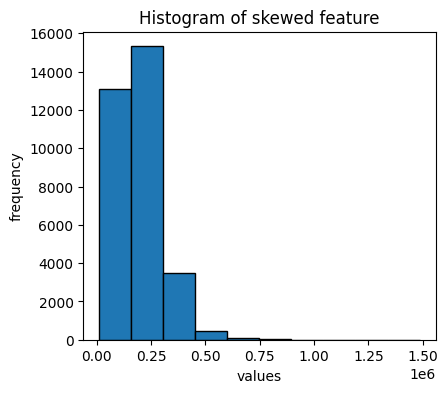

In [43]:
import matplotlib.pyplot as plt
#plot histogram to visualize the distribution
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df['fnlwgt'],bins=10,edgecolor='k')
plt.xlabel('values')
plt.ylabel('frequency')
plt.title('Histogram of skewed feature')

In [44]:
# Apply log transformation
import numpy as np
df['log_feature1']=np.log(df['fnlwgt'])
df['log_feature1']

,log_feature1
0,11.258240
1,11.330336
2,12.281393
3,12.366153
4,12.732011
...,...
32556,12.458006
32557,11.947134
32558,11.931044
32559,12.213495


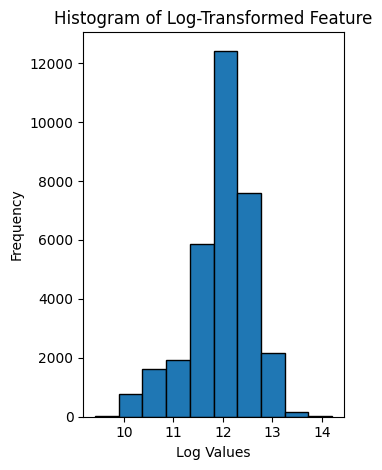

In [45]:
# Plot histogram of log-transformed feature
plt.subplot(1, 2, 2)
plt.hist(df['log_feature1'], bins=10, edgecolor='black')
plt.title('Histogram of Log-Transformed Feature')
plt.xlabel('Log Values')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

<Axes: >

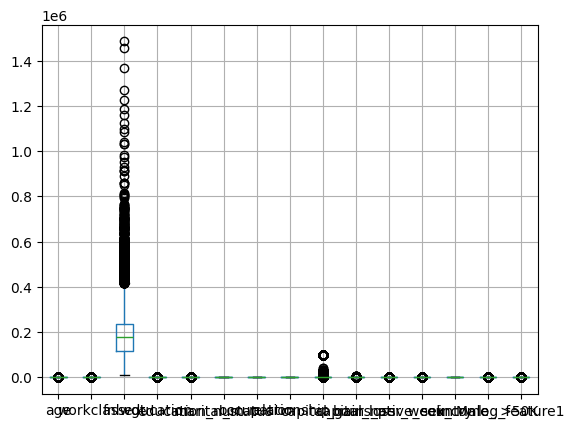

In [46]:
df.boxplot()

In [47]:
## outlier capping
def outlier_capping(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    IQR=q3-q1
    lower_extreme=q1-1.5*IQR
    upper_extreme=q3+1.5*IQR
    df[column]=df[column].apply(lambda x:lower_extreme if  x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(['int','float']):
    outlier_capping(df,col)

<Axes: >

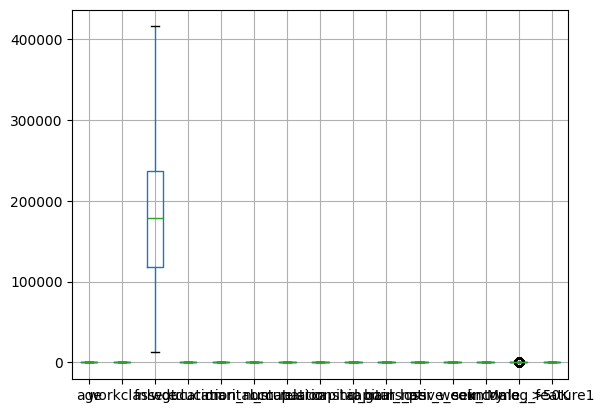

In [48]:
df.boxplot()

In [49]:
#!pip install ppscore

In [ ]:
import ppscore as pps
pps_matrix = pps.matrix(data)
pps_matrix

In [51]:
# Calculate the correlation matrix (Pearson correlation)
import seaborn as sns
correlation_matrix = data.corr(numeric_only=True)

# Display the correlation matrix
print("\nCorrelation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                     age    fnlwgt  education_num  capital_gain  capital_loss  \
age             1.000000 -0.076447       0.036224      0.077676      0.057745   
fnlwgt         -0.076447  1.000000      -0.043388      0.000429     -0.010260   
education_num   0.036224 -0.043388       1.000000      0.122664      0.079892   
capital_gain    0.077676  0.000429       0.122664      1.000000     -0.031639   
capital_loss    0.057745 -0.010260       0.079892     -0.031639      1.000000   
hours_per_week  0.068515 -0.018898       0.148422      0.078408      0.054229   

                hours_per_week  
age                   0.068515  
fnlwgt               -0.018898  
education_num         0.148422  
capital_gain          0.078408  
capital_loss          0.054229  
hours_per_week        1.000000  


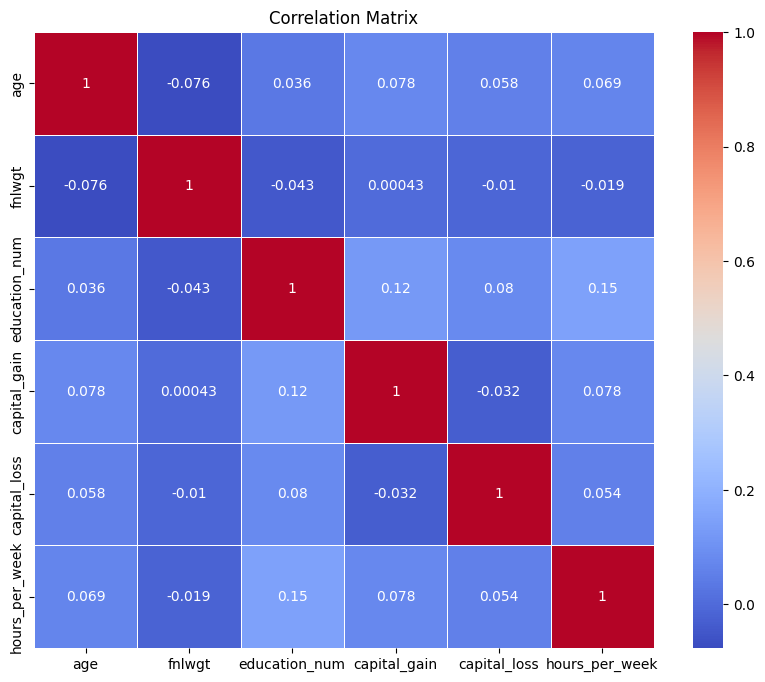

In [52]:
# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()